# 🩺 Problèmes Inverses avec Approches Hybrides

## Dataset: NIH Chest X-rays (112,120 images)
## Plateforme: Google Colab Pro
## Méthode de téléchargement: **kagglehub** (SIMPLIFIÉ)

---

### 🎉 NOUVELLE MÉTHODE SIMPLIFIÉE!

Ce notebook utilise **`kagglehub`** pour télécharger le dataset - **beaucoup plus simple** que l'API Kaggle classique!

✅ **PAS BESOIN** de créer `kaggle.json`  
✅ **PAS BESOIN** de configurer des credentials  
✅ **Authentification automatique** via navigateur  
✅ **Juste 2 lignes de code** pour tout télécharger!  

---

### 📋 Ce notebook implémente:

1. **Téléchargement automatique simplifié** avec kagglehub
2. **Méthodes classiques** d'optimisation (Gradient Descent, Forward-Backward)
3. **Réseau Unrolled** (déroulement d'algorithmes itératifs)
4. **Plug-and-Play** avec denoiser DnCNN

---

### ⚡ Prérequis:

- Google Colab (gratuit) ou Colab Pro (recommandé)
- GPU activé (Runtime → Change runtime type → GPU)
- Compte Kaggle (gratuit)
- ~50GB d'espace disque sur Colab

---

### 🚀 Instructions rapides:

1. **Activez le GPU**: Runtime → Change runtime type → GPU (T4)
2. **Exécutez Cellule 1**: Installation des dépendances (~1-2 min)
3. **Exécutez Cellule 2**: Téléchargement du dataset (~20-30 min)
   - À la première utilisation, authentifiez-vous sur Kaggle via le lien
4. **Exécutez les cellules suivantes** dans l'ordre

⏱️ **Temps total**: ~45-90 minutes sur GPU T4/V100


## 📦 Cellule 1: Installation des dépendances


In [1]:
# Installation de toutes les dépendances nécessaires
!pip install -q kagglehub  # Pour téléchargement simplifié du dataset
!pip install -q torch torchvision torchaudio  # PyTorch pour deep learning
!pip install -q scikit-image opencv-python matplotlib seaborn  # Traitement d'images et visualisation
!pip install -q tqdm scipy pandas pillow  # Utilitaires

print("✅ Toutes les dépendances sont installées!")

✅ Toutes les dépendances sont installées!


## 🚀 Cellule 2: Téléchargement du dataset avec kagglehub

### 🎉 MÉTHODE ULTRA-SIMPLIFIÉE!

**Plus besoin de `kaggle.json`!** kagglehub gère tout automatiquement.

### À la première utilisation:
1. Un lien d'authentification s'affichera
2. Cliquez sur le lien → Connectez-vous sur Kaggle
3. Acceptez les permissions
4. Revenez sur Colab → Le téléchargement démarrera

⏱️ **Temps estimé**: 15-30 minutes pour 42GB


In [2]:
import kagglehub
import os
import shutil

print("📥 Téléchargement du dataset NIH Chest X-rays avec kagglehub...")
print("⚠️  Attention: Ce dataset fait ~42GB, le téléchargement peut prendre 15-30 minutes")
print("🔄 En cours...\n")

# Téléchargement automatique (dernière version)
dataset_path = kagglehub.dataset_download("nih-chest-xrays/data")

print(f"✅ Dataset téléchargé!")
print(f"📂 Localisation: {dataset_path}\n")

# Afficher la structure du dataset
print("📊 Structure du dataset:")
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files[:5]:  # Afficher seulement les 5 premiers fichiers
        print(f'{subindent}{file}')
    if len(files) > 5:
        print(f'{subindent}... et {len(files) - 5} autres fichiers')
    if level > 2:  # Limiter la profondeur
        break

# Organiser les images dans un dossier unique
print("\n🔄 Organisation des images...")

# Créer un dossier pour toutes les images
all_images_dir = '/content/nih_chest_xrays_all_images'
os.makedirs(all_images_dir, exist_ok=True)

# Chercher et copier toutes les images PNG
image_count = 0
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith('.png'):
            src = os.path.join(root, file)
            dst = os.path.join(all_images_dir, file)
            if not os.path.exists(dst):
                shutil.copy2(src, dst)
                image_count += 1
                if image_count % 10000 == 0:
                    print(f"   Copié {image_count} images...")

print(f"✅ Organisation terminée!")
print(f"📊 Nombre total d'images: {image_count}")
print(f"📂 Toutes les images sont dans: {all_images_dir}")

# Chercher le fichier de métadonnées
metadata_file = None
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if 'Data_Entry' in file and file.endswith('.csv'):
            metadata_file = os.path.join(root, file)
            break
    if metadata_file:
        break

if metadata_file:
    print(f"📋 Métadonnées trouvées: {metadata_file}")
else:
    print("⚠️  Fichier de métadonnées non trouvé")

# Sauvegarder les chemins pour les cellules suivantes
DATASET_PATH = all_images_dir
METADATA_PATH = metadata_file

print(f"\n✅ Configuration complète!")
print(f"   DATASET_PATH = '{DATASET_PATH}'")
print(f"   METADATA_PATH = '{METADATA_PATH}'")

📥 Téléchargement du dataset NIH Chest X-rays avec kagglehub...
⚠️  Attention: Ce dataset fait ~42GB, le téléchargement peut prendre 15-30 minutes
🔄 En cours...



100%|██████████| 42.0G/42.0G [31:42<00:00, 23.7MB/s]

Extracting files...


✅ Dataset téléchargé!
📂 Localisation: /root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3

📊 Structure du dataset:
3/
  LOG_CHESTXRAY.pdf
  Data_Entry_2017.csv
  ARXIV_V5_CHESTXRAY.pdf
  BBox_List_2017.csv
  FAQ_CHESTXRAY.pdf
  ... et 3 autres fichiers
  images_012/
    images/
      00029083_000.png
      00028939_000.png
      00030047_000.png
      00028187_002.png
      00030573_004.png
      ... et 7116 autres fichiers
  images_009/
    images/
      00018494_011.png
      00019006_004.png
      00020197_002.png
      00020213_003.png
      00018622_003.png
      ... et 9995 autres fichiers
  images_010/
    images/
      00023622_000.png
      00021274_014.png
      00022374_007.png
      00023781_000.png
      00021008_002.png
      ... et 9995 autres fichiers
  images_007/
    images/
      00014558_007.png
      00014472_000.png
      00015081_012.png
      00014023_002.png
      00015826_029.png
      ... et 9995 autres fichiers
  images_008/
    images/
      000

In [3]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Configuration du device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device utilisé: {device}")
if torch.cuda.is_available():
    print(f"🚀 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 Mémoire GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️  Aucun GPU détecté!")


🖥️  Device utilisé: cuda
🚀 GPU: Tesla T4
💾 Mémoire GPU: 15.83 GB


In [4]:
CONFIG = {
    'DATASET_PATH': '/content/nih_chest_xrays_all_images',
    'METADATA_PATH': None,
    'MAX_TRAIN_SAMPLES': 10000,
    'MAX_TEST_SAMPLES': 1000,
    'IMAGE_SIZE': 128,
    'BATCH_SIZE': 8,
    'NUM_EPOCHS': 20,
    'LEARNING_RATE': 1e-4,
    'NOISE_LEVEL': 0.05,
    'BLUR_KERNEL_SIZE': 7,
    'DEGRADATION_TYPE': 'blur_noise',
    'MAX_ITER_CLASSICAL': 50,
    'LAMBDA_REG': 0.001,
    'NUM_UNROLLED_LAYERS': 5,
    'PNP_ITERATIONS': 10,
    'PNP_RHO': 0.01,
    'SAVE_DIR': '/content/results',
    'CHECKPOINT_DIR': '/content/checkpoints'
}

os.makedirs(CONFIG['SAVE_DIR'], exist_ok=True)
os.makedirs(CONFIG['CHECKPOINT_DIR'], exist_ok=True)

print("✅ Configuration chargée")
print(f"   Dataset: {CONFIG['DATASET_PATH']}")
print(f"   Images: {CONFIG['MAX_TRAIN_SAMPLES']} train + {CONFIG['MAX_TEST_SAMPLES']} test")


✅ Configuration chargée
   Dataset: /content/nih_chest_xrays_all_images
   Images: 10000 train + 1000 test


In [5]:
class ChestXrayInverseProblemDataset(Dataset):
    def __init__(self, image_dir, transform=None, max_samples=None):
        self.image_dir = image_dir
        self.transform = transform

        if not os.path.exists(image_dir):
            raise FileNotFoundError(f"❌ {image_dir} n'existe pas!")

        self.image_files = [f for f in os.listdir(image_dir)
                           if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if max_samples and max_samples < len(self.image_files):
            np.random.seed(42)
            indices = np.random.choice(len(self.image_files), max_samples, replace=False)
            self.image_files = [self.image_files[i] for i in indices]

        print(f"✅ Dataset: {len(self.image_files)} images")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        try:
            image = Image.open(img_path).convert('L')
            if self.transform:
                image = self.transform(image)
            return image
        except:
            return torch.zeros(1, CONFIG['IMAGE_SIZE'], CONFIG['IMAGE_SIZE'])

# Création des datasets
transform = transforms.Compose([
    transforms.Resize((CONFIG['IMAGE_SIZE'], CONFIG['IMAGE_SIZE'])),
    transforms.ToTensor()
])

full_dataset = ChestXrayInverseProblemDataset(
    CONFIG['DATASET_PATH'], transform=transform,
    max_samples=CONFIG['MAX_TRAIN_SAMPLES'] + CONFIG['MAX_TEST_SAMPLES']
)

train_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset, [CONFIG['MAX_TRAIN_SAMPLES'], CONFIG['MAX_TEST_SAMPLES']],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['BATCH_SIZE'],
                          shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

print(f"✅ Train: {len(train_dataset)}, Test: {len(test_dataset)}")


✅ Dataset: 11000 images
✅ Train: 10000, Test: 1000


In [6]:
def create_degradation_operator(config):
    def gaussian_kernel(size, sigma=1.0):
        ax = np.arange(-size // 2 + 1., size // 2 + 1.)
        xx, yy = np.meshgrid(ax, ax)
        kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
        return kernel / kernel.sum()

    kernel_size = config['BLUR_KERNEL_SIZE']
    kernel = gaussian_kernel(kernel_size, sigma=kernel_size/6)
    kernel = torch.FloatTensor(kernel).unsqueeze(0).unsqueeze(0).to(device)

    def apply_blur(img):
        return nn.functional.conv2d(img, kernel, padding=kernel_size // 2)

    def add_noise(img, noise_level):
        return img + torch.randn_like(img) * noise_level

    def forward_operator(x):
        degraded = x
        if config['DEGRADATION_TYPE'] in ['blur', 'blur_noise']:
            degraded = apply_blur(degraded)
        if config['DEGRADATION_TYPE'] in ['noise', 'blur_noise']:
            degraded = add_noise(degraded, config['NOISE_LEVEL'])
        return torch.clamp(degraded, 0, 1)

    return forward_operator, kernel

forward_op, blur_kernel = create_degradation_operator(CONFIG)
print("✅ Opérateur de dégradation créé")


✅ Opérateur de dégradation créé


In [7]:
class ClassicalOptimization:
    def __init__(self, forward_op, lambda_reg=0.01):
        self.forward_op = forward_op
        self.lambda_reg = lambda_reg

    def gradient_descent(self, y, x_init, max_iter=50, lr=0.01):
        x = x_init.clone().requires_grad_(True)
        optimizer = optim.Adam([x], lr=lr)
        losses = []

        for i in range(max_iter):
            optimizer.zero_grad()
            y_pred = self.forward_op(x)
            data_term = torch.mean((y_pred - y) ** 2)
            reg_term = self.lambda_reg * torch.mean(x ** 2)
            loss = data_term + reg_term
            loss.backward()
            optimizer.step()
            with torch.no_grad():
                x.clamp_(0, 1)
            losses.append(loss.item())

        return x.detach(), losses

print("✅ Méthodes classiques définies")


✅ Méthodes classiques définies


In [8]:
class UnrolledLayer(nn.Module):
    def __init__(self, num_channels=1):
        super(UnrolledLayer, self).__init__()
        self.prox_net = nn.Sequential(
            nn.Conv2d(num_channels, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, num_channels, 3, padding=1)
        )
        self.alpha = nn.Parameter(torch.tensor(0.1))
        self.beta = nn.Parameter(torch.tensor(0.1))

    def forward(self, x, y, forward_op):
        residual = forward_op(x) - y
        grad = self.alpha * residual
        x_grad = x - grad
        x_prox = self.prox_net(x_grad)
        x_new = x_grad + self.beta * x_prox
        return torch.clamp(x_new, 0, 1)

class UnrolledNetwork(nn.Module):
    def __init__(self, num_layers=5, num_channels=1):
        super(UnrolledNetwork, self).__init__()
        self.num_layers = num_layers
        self.layers = nn.ModuleList([UnrolledLayer(num_channels) for _ in range(num_layers)])

    def forward(self, y, forward_op):
        x = y.clone()
        for layer in self.layers:
            x = layer(x, y, forward_op)
        return x

print("✅ Réseau Unrolled défini")


✅ Réseau Unrolled défini


In [9]:
class DnCNN(nn.Module):
    def __init__(self, num_channels=1, num_features=64, num_layers=17):
        super(DnCNN, self).__init__()
        layers = []
        layers.append(nn.Conv2d(num_channels, num_features, 3, padding=1, bias=False))
        layers.append(nn.ReLU(inplace=True))
        for _ in range(num_layers - 2):
            layers.append(nn.Conv2d(num_features, num_features, 3, padding=1, bias=False))
            layers.append(nn.BatchNorm2d(num_features))
            layers.append(nn.ReLU(inplace=True))
        layers.append(nn.Conv2d(num_features, num_channels, 3, padding=1, bias=False))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        noise = self.network(x)
        return x - noise

class PlugAndPlayReconstruction:
    def __init__(self, forward_op, denoiser, rho=0.01):
        self.forward_op = forward_op
        self.denoiser = denoiser
        self.rho = rho

    def reconstruct(self, y, num_iterations=10):
        x = y.clone()
        v = y.clone()
        u = torch.zeros_like(y)

        for i in range(num_iterations):
            y_pred = self.forward_op(x)
            grad = 2 * (y_pred - y) + self.rho * (x - v + u)
            x = x - 0.1 * grad
            x = torch.clamp(x, 0, 1)
            with torch.no_grad():
                v = self.denoiser(x + u)
                v = torch.clamp(v, 0, 1)
            u = u + (x - v)

        return x, []

print("✅ DnCNN et Plug-and-Play définis")


✅ DnCNN et Plug-and-Play définis


In [10]:
def train_denoiser(model, train_loader, num_epochs, device, config):
    """Entraîne le denoiser DnCNN"""

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=config['LEARNING_RATE'])
    criterion = nn.MSELoss()

    forward_op, _ = create_degradation_operator(config)

    train_losses = []

    print("🚀 Entraînement du Denoiser DnCNN...")
    print(f"   Epochs: {num_epochs}")
    print(f"   Learning rate: {config['LEARNING_RATE']}")
    print(f"   Batch size: {config['BATCH_SIZE']}\n")

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for batch_idx, clean_imgs in enumerate(progress_bar):
            clean_imgs = clean_imgs.to(device)

            # Création d'images dégradées
            with torch.no_grad():
                noisy_imgs = forward_op(clean_imgs)

            # Forward pass
            optimizer.zero_grad()
            denoised_imgs = model(noisy_imgs)

            # Loss: reconstruction de l'image propre
            loss = criterion(denoised_imgs, clean_imgs)

            # Backward pass
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            progress_bar.set_postfix({'loss': loss.item()})

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        print(f"   Epoch {epoch+1}/{num_epochs}: Loss = {avg_loss:.6f}")

        # Sauvegarde du modèle tous les 5 epochs
        if (epoch + 1) % 5 == 0:
            checkpoint_path = f"{config['CHECKPOINT_DIR']}/denoiser_epoch_{epoch+1}.pth"
            torch.save(model.state_dict(), checkpoint_path)
            print(f"   💾 Modèle sauvegardé: {checkpoint_path}")

    print("\n✅ Entraînement du Denoiser terminé!")
    return train_losses


# Création et entraînement du denoiser
print("\n" + "="*80)
print(" 🧠 ENTRAÎNEMENT DU DENOISER DnCNN")
print("="*80 + "\n")

denoiser = DnCNN(num_channels=1).to(device)
print(f"📊 Nombre de paramètres: {sum(p.numel() for p in denoiser.parameters()):,}")

denoiser_losses = train_denoiser(
    denoiser,
    train_loader,
    CONFIG['NUM_EPOCHS'],
    device,
    CONFIG
)



 🧠 ENTRAÎNEMENT DU DENOISER DnCNN

📊 Nombre de paramètres: 556,032
🚀 Entraînement du Denoiser DnCNN...
   Epochs: 20
   Learning rate: 0.0001
   Batch size: 8



Epoch 1/20: 100%|██████████| 1250/1250 [03:20<00:00,  6.23it/s, loss=0.000759]


   Epoch 1/20: Loss = 0.001949


Epoch 2/20: 100%|██████████| 1250/1250 [03:13<00:00,  6.44it/s, loss=0.000665]


   Epoch 2/20: Loss = 0.000731


...

   Epoch 18/20: Loss = 0.000431


Epoch 19/20: 100%|██████████| 1250/1250 [03:08<00:00,  6.62it/s, loss=0.000418]


   Epoch 19/20: Loss = 0.000428


Epoch 20/20: 100%|██████████| 1250/1250 [03:09<00:00,  6.59it/s, loss=0.00039]


   Epoch 20/20: Loss = 0.000425
   💾 Modèle sauvegardé: /content/checkpoints/denoiser_epoch_20.pth

✅ Entraînement du Denoiser terminé!


In [11]:
def train_unrolled_network(model, train_loader, num_epochs, device, config):
    """Entraîne le réseau déroulé"""

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=config['LEARNING_RATE'])
    criterion = nn.MSELoss()

    forward_op, _ = create_degradation_operator(config)

    train_losses = []

    print("🚀 Entraînement du Réseau Unrolled...")
    print(f"   Epochs: {num_epochs}")
    print(f"   Couches déroulées: {config['NUM_UNROLLED_LAYERS']}")
    print(f"   Learning rate: {config['LEARNING_RATE']}\n")

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for batch_idx, clean_imgs in enumerate(progress_bar):
            clean_imgs = clean_imgs.to(device)

            # Création d'images dégradées
            with torch.no_grad():
                degraded_imgs = forward_op(clean_imgs)

            # Forward pass
            optimizer.zero_grad()
            reconstructed_imgs = model(degraded_imgs, forward_op)

            # Loss: reconstruction de l'image propre
            loss = criterion(reconstructed_imgs, clean_imgs)

            # Backward pass
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            progress_bar.set_postfix({'loss': loss.item()})

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        print(f"   Epoch {epoch+1}/{num_epochs}: Loss = {avg_loss:.6f}")

        # Sauvegarde du modèle tous les 5 epochs
        if (epoch + 1) % 5 == 0:
            checkpoint_path = f"{config['CHECKPOINT_DIR']}/unrolled_epoch_{epoch+1}.pth"
            torch.save(model.state_dict(), checkpoint_path)
            print(f"   💾 Modèle sauvegardé: {checkpoint_path}")

    print("\n✅ Entraînement du Réseau Unrolled terminé!")
    return train_losses


# Création et entraînement du réseau unrolled
print("\n" + "="*80)
print(" 🔄 ENTRAÎNEMENT DU RÉSEAU UNROLLED")
print("="*80 + "\n")

unrolled_model = UnrolledNetwork(
    num_layers=CONFIG['NUM_UNROLLED_LAYERS']
).to(device)
print(f"📊 Nombre de paramètres: {sum(p.numel() for p in unrolled_model.parameters()):,}")

unrolled_losses = train_unrolled_network(
    unrolled_model,
    train_loader,
    CONFIG['NUM_EPOCHS'],
    device,
    CONFIG
)



 🔄 ENTRAÎNEMENT DU RÉSEAU UNROLLED

📊 Nombre de paramètres: 190,735
🚀 Entraînement du Réseau Unrolled...
   Epochs: 20
   Couches déroulées: 5
   Learning rate: 0.0001



Epoch 1/20: 100%|██████████| 1250/1250 [02:23<00:00,  8.73it/s, loss=0.000591]


   Epoch 1/20: Loss = 0.001067


Epoch 2/20: 100%|██████████| 1250/1250 [02:20<00:00,  8.92it/s, loss=0.00052]


   Epoch 2/20: Loss = 0.000578


...

   Epoch 18/20: Loss = 0.000473


Epoch 19/20: 100%|██████████| 1250/1250 [02:21<00:00,  8.81it/s, loss=0.00042]


   Epoch 19/20: Loss = 0.000471


Epoch 20/20: 100%|██████████| 1250/1250 [02:22<00:00,  8.75it/s, loss=0.000463]

   Epoch 20/20: Loss = 0.000469
   💾 Modèle sauvegardé: /content/checkpoints/unrolled_epoch_20.pth

✅ Entraînement du Réseau Unrolled terminé!


In [12]:
def calculate_metrics(original, reconstructed):
    """Calcule PSNR et SSIM entre deux images"""

    # Conversion en numpy
    if torch.is_tensor(original):
        original = original.cpu().numpy()
    if torch.is_tensor(reconstructed):
        reconstructed = reconstructed.cpu().numpy()

    # Suppression des dimensions batch et channel si présentes
    if original.ndim == 4:
        original = original[0, 0]
        reconstructed = reconstructed[0, 0]
    elif original.ndim == 3:
        original = original[0]
        reconstructed = reconstructed[0]

    # Calcul des métriques
    psnr_value = psnr(original, reconstructed, data_range=1.0)
    ssim_value = ssim(original, reconstructed, data_range=1.0)

    return psnr_value, ssim_value


def evaluate_reconstruction(method_name, original, degraded, reconstructed):
    """Évalue et affiche les métriques pour une méthode"""

    psnr_deg, ssim_deg = calculate_metrics(original, degraded)
    psnr_rec, ssim_rec = calculate_metrics(original, reconstructed)

    print(f"\n📊 {method_name}:")
    print(f"   Dégradée  -> PSNR: {psnr_deg:.2f} dB, SSIM: {ssim_deg:.4f}")
    print(f"   Restaurée -> PSNR: {psnr_rec:.2f} dB, SSIM: {ssim_rec:.4f}")
    print(f"   Amélioration: +{psnr_rec - psnr_deg:.2f} dB")

    return {
        'method': method_name,
        'psnr_degraded': psnr_deg,
        'ssim_degraded': ssim_deg,
        'psnr_reconstructed': psnr_rec,
        'ssim_reconstructed': ssim_rec,
        'improvement': psnr_rec - psnr_deg
    }

print("✅ Fonctions d'évaluation définies")


✅ Fonctions d'évaluation définies


In [13]:
def visualize_reconstruction(original, degraded, reconstructed, method_name, save_path=None):
    """Visualise la comparaison originale/dégradée/restaurée"""

    # Conversion en numpy pour affichage
    def to_numpy(img):
        if torch.is_tensor(img):
            img = img.cpu().numpy()
        if img.ndim == 4:
            img = img[0, 0]
        elif img.ndim == 3:
            img = img[0]
        return img

    original_np = to_numpy(original)
    degraded_np = to_numpy(degraded)
    reconstructed_np = to_numpy(reconstructed)

    # Calcul des métriques
    psnr_rec, ssim_rec = calculate_metrics(original, reconstructed)

    # Affichage
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(original_np, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Image Originale', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(degraded_np, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title('Image Dégradée', fontsize=12, fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(reconstructed_np, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f'{method_name}\nPSNR: {psnr_rec:.2f} dB | SSIM: {ssim_rec:.4f}',
                     fontsize=12, fontweight='bold')
    axes[2].axis('off')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"💾 Sauvegardé: {save_path}")

    plt.show()


def plot_training_curves(losses, title, save_path=None):
    """Affiche les courbes d'entraînement"""

    plt.figure(figsize=(10, 6))
    plt.plot(losses, linewidth=2, color='blue')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (MSE)', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"💾 Sauvegardé: {save_path}")

    plt.show()

print("✅ Fonctions de visualisation définies")


✅ Fonctions de visualisation définies



 📈 COURBES D'ENTRAÎNEMENT

💾 Sauvegardé: /content/results/denoiser_training.png


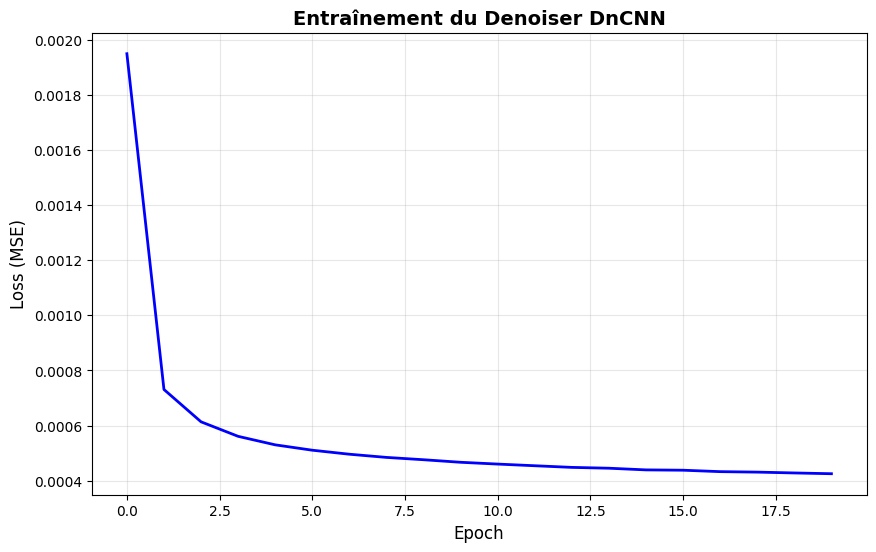

💾 Sauvegardé: /content/results/unrolled_training.png


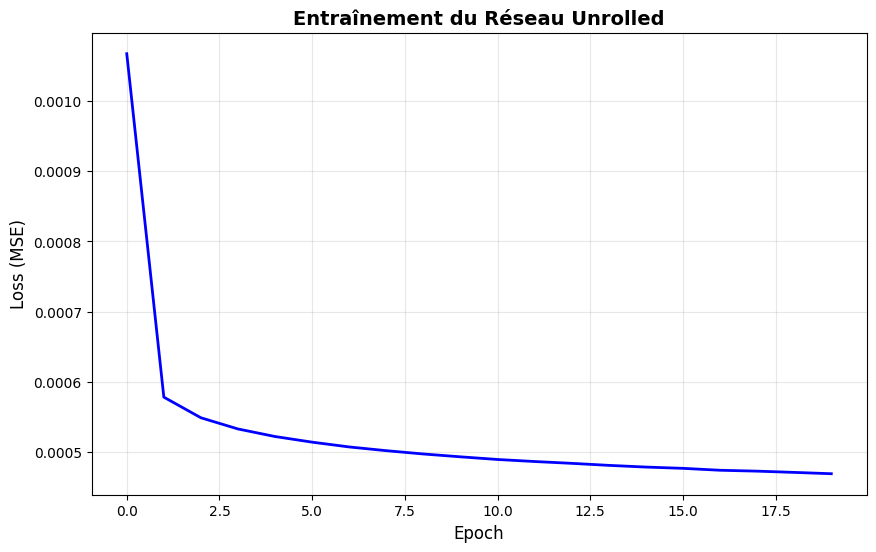

✅ Courbes d'entraînement affichées


In [14]:
print("\n" + "="*80)
print(" 📈 COURBES D'ENTRAÎNEMENT")
print("="*80 + "\n")

# Courbe du Denoiser
plot_training_curves(
    denoiser_losses,
    "Entraînement du Denoiser DnCNN",
    save_path=f"{CONFIG['SAVE_DIR']}/denoiser_training.png"
)

# Courbe du Unrolled
plot_training_curves(
    unrolled_losses,
    "Entraînement du Réseau Unrolled",
    save_path=f"{CONFIG['SAVE_DIR']}/unrolled_training.png"
)

print("✅ Courbes d'entraînement affichées")


In [15]:
def compare_all_methods(test_image, config):
    """Compare toutes les méthodes sur une image de test"""

    # Préparation de l'image
    test_image = test_image.unsqueeze(0).to(device)

    # Opérateur de dégradation
    forward_op, _ = create_degradation_operator(config)

    # Création de l'image dégradée
    with torch.no_grad():
        degraded_image = forward_op(test_image)

    results = {}

    # 1. Méthode Classique: Gradient Descent
    print("\n🔵 Méthode 1: Optimisation Classique (Gradient Descent)")
    classical = ClassicalOptimization(forward_op, lambda_reg=config['LAMBDA_REG'])
    x_classical, losses_classical = classical.gradient_descent(
        degraded_image,
        degraded_image.clone(),
        max_iter=config['MAX_ITER_CLASSICAL'],
        lr=0.01
    )
    results['classical'] = evaluate_reconstruction(
        "Optimisation Classique", test_image, degraded_image, x_classical
    )

    # 2. Réseau Unrolled
    print("\n🟢 Méthode 2: Réseau Unrolled")
    unrolled_model.eval()
    with torch.no_grad():
        x_unrolled = unrolled_model(degraded_image, forward_op)

    results['unrolled'] = evaluate_reconstruction(
        "Réseau Unrolled", test_image, degraded_image, x_unrolled
    )

    # 3. Plug-and-Play avec DnCNN
    print("\n🟣 Méthode 3: Plug-and-Play (DnCNN)")
    denoiser.eval()
    pnp = PlugAndPlayReconstruction(forward_op, denoiser, rho=config['PNP_RHO'])
    x_pnp, _ = pnp.reconstruct(degraded_image, num_iterations=config['PNP_ITERATIONS'])

    results['pnp'] = evaluate_reconstruction(
        "Plug-and-Play", test_image, degraded_image, x_pnp
    )

    # Visualisation comparative
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    def to_numpy(img):
        if torch.is_tensor(img):
            img = img.cpu().numpy()
        if img.ndim == 4:
            img = img[0, 0]
        elif img.ndim == 3:
            img = img[0]
        return img

    # Ligne 1: Images
    axes[0, 0].imshow(to_numpy(test_image), cmap='gray', vmin=0, vmax=1)
    axes[0, 0].set_title('Originale', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(to_numpy(degraded_image), cmap='gray', vmin=0, vmax=1)
    axes[0, 1].set_title('Dégradée', fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(to_numpy(x_classical), cmap='gray', vmin=0, vmax=1)
    axes[0, 2].set_title(f"Classique\nPSNR: {results['classical']['psnr_reconstructed']:.2f} dB",
                        fontsize=12, fontweight='bold')
    axes[0, 2].axis('off')

    # Ligne 2: Méthodes avancées
    axes[1, 0].imshow(to_numpy(x_unrolled), cmap='gray', vmin=0, vmax=1)
    axes[1, 0].set_title(f"Unrolled\nPSNR: {results['unrolled']['psnr_reconstructed']:.2f} dB",
                        fontsize=12, fontweight='bold')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(to_numpy(x_pnp), cmap='gray', vmin=0, vmax=1)
    axes[1, 1].set_title(f"Plug-and-Play\nPSNR: {results['pnp']['psnr_reconstructed']:.2f} dB",
                        fontsize=12, fontweight='bold')
    axes[1, 1].axis('off')

    # Graphique de comparaison
    methods = ['Classique', 'Unrolled', 'PnP']
    psnr_values = [results[k]['psnr_reconstructed'] for k in ['classical', 'unrolled', 'pnp']]

    axes[1, 2].bar(methods, psnr_values, color=['blue', 'green', 'purple'], alpha=0.7)
    axes[1, 2].set_ylabel('PSNR (dB)', fontsize=12)
    axes[1, 2].set_title('Comparaison des Méthodes', fontsize=12, fontweight='bold')
    axes[1, 2].grid(axis='y', alpha=0.3)
    axes[1, 2].set_ylim([min(psnr_values) - 2, max(psnr_values) + 2])

    plt.tight_layout()
    save_path = f"{config['SAVE_DIR']}/comparison_all_methods.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"\n💾 Comparaison sauvegardée: {save_path}")
    plt.show()

    return results

print("✅ Fonction de comparaison définie")


✅ Fonction de comparaison définie



 📊 ÉVALUATION SUR LE DATASET DE TEST


 📸 IMAGE DE TEST 1/5

🔵 Méthode 1: Optimisation Classique (Gradient Descent)

📊 Optimisation Classique:
   Dégradée  -> PSNR: 23.92 dB, SSIM: 0.6312
   Restaurée -> PSNR: 19.75 dB, SSIM: 0.4175
   Amélioration: +-4.17 dB

🟢 Méthode 2: Réseau Unrolled

📊 Réseau Unrolled:
   Dégradée  -> PSNR: 23.92 dB, SSIM: 0.6312
   Restaurée -> PSNR: 30.70 dB, SSIM: 0.8984
   Amélioration: +6.79 dB

🟣 Méthode 3: Plug-and-Play (DnCNN)

📊 Plug-and-Play:
   Dégradée  -> PSNR: 23.92 dB, SSIM: 0.6312
   Restaurée -> PSNR: 17.60 dB, SSIM: 0.3138
   Amélioration: +-6.32 dB

💾 Comparaison sauvegardée: /content/results/comparison_all_methods.png


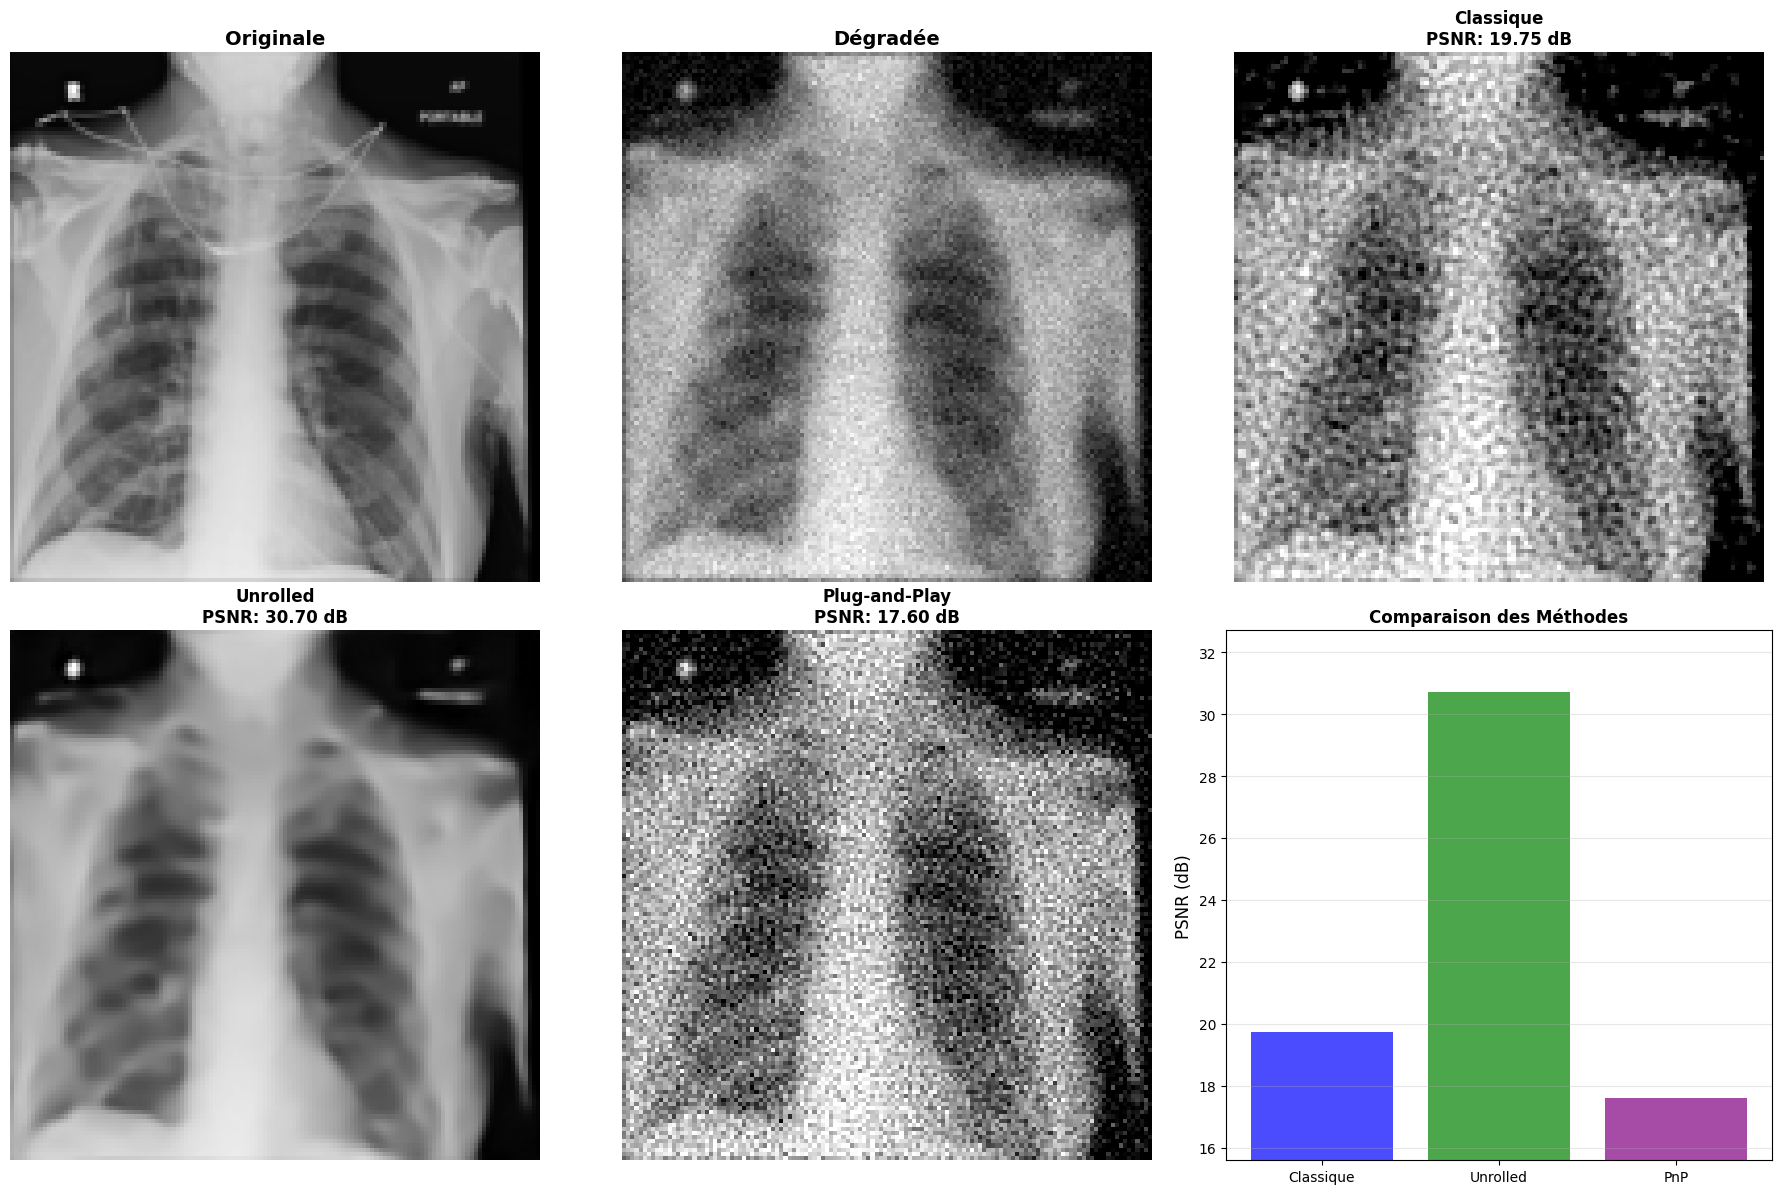


 📸 IMAGE DE TEST 2/5

🔵 Méthode 1: Optimisation Classique (Gradient Descent)

📊 Optimisation Classique:
   Dégradée  -> PSNR: 24.80 dB, SSIM: 0.5401
   Restaurée -> PSNR: 19.43 dB, SSIM: 0.3045
   Amélioration: +-5.37 dB

🟢 Méthode 2: Réseau Unrolled

📊 Réseau Unrolled:
   Dégradée  -> PSNR: 24.80 dB, SSIM: 0.5401
   Restaurée -> PSNR: 30.85 dB, SSIM: 0.8454
   Amélioration: +6.05 dB

🟣 Méthode 3: Plug-and-Play (DnCNN)

📊 Plug-and-Play:
   Dégradée  -> PSNR: 24.80 dB, SSIM: 0.5401
   Restaurée -> PSNR: 17.46 dB, SSIM: 0.2137
   Amélioration: +-7.33 dB

💾 Comparaison sauvegardée: /content/results/comparison_all_methods.png


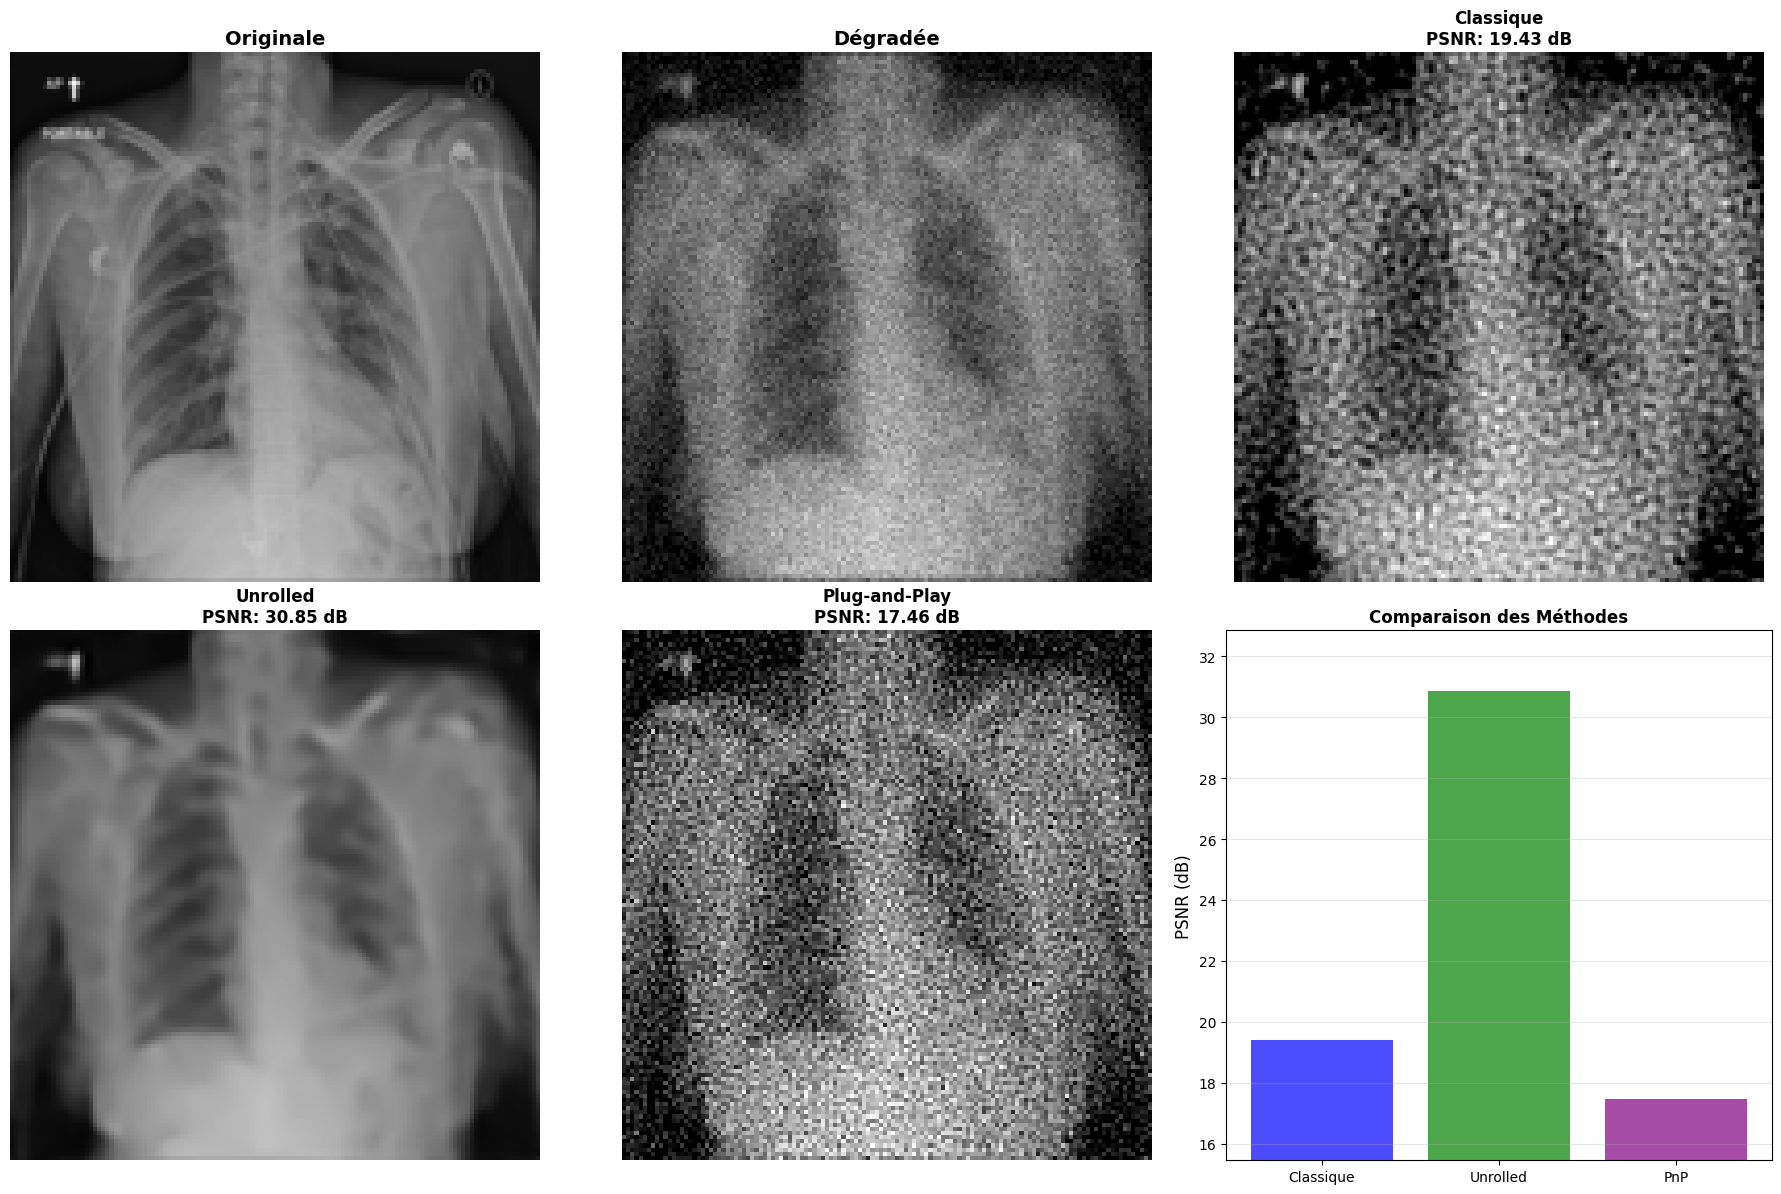


 📸 IMAGE DE TEST 3/5

🔵 Méthode 1: Optimisation Classique (Gradient Descent)

📊 Optimisation Classique:
   Dégradée  -> PSNR: 24.09 dB, SSIM: 0.5120
   Restaurée -> PSNR: 19.51 dB, SSIM: 0.2640
   Amélioration: +-4.59 dB

🟢 Méthode 2: Réseau Unrolled

📊 Réseau Unrolled:
   Dégradée  -> PSNR: 24.09 dB, SSIM: 0.5120
   Restaurée -> PSNR: 33.50 dB, SSIM: 0.9110
   Amélioration: +9.41 dB

🟣 Méthode 3: Plug-and-Play (DnCNN)

📊 Plug-and-Play:
   Dégradée  -> PSNR: 24.09 dB, SSIM: 0.5120
   Restaurée -> PSNR: 17.58 dB, SSIM: 0.1897
   Amélioration: +-6.51 dB

💾 Comparaison sauvegardée: /content/results/comparison_all_methods.png


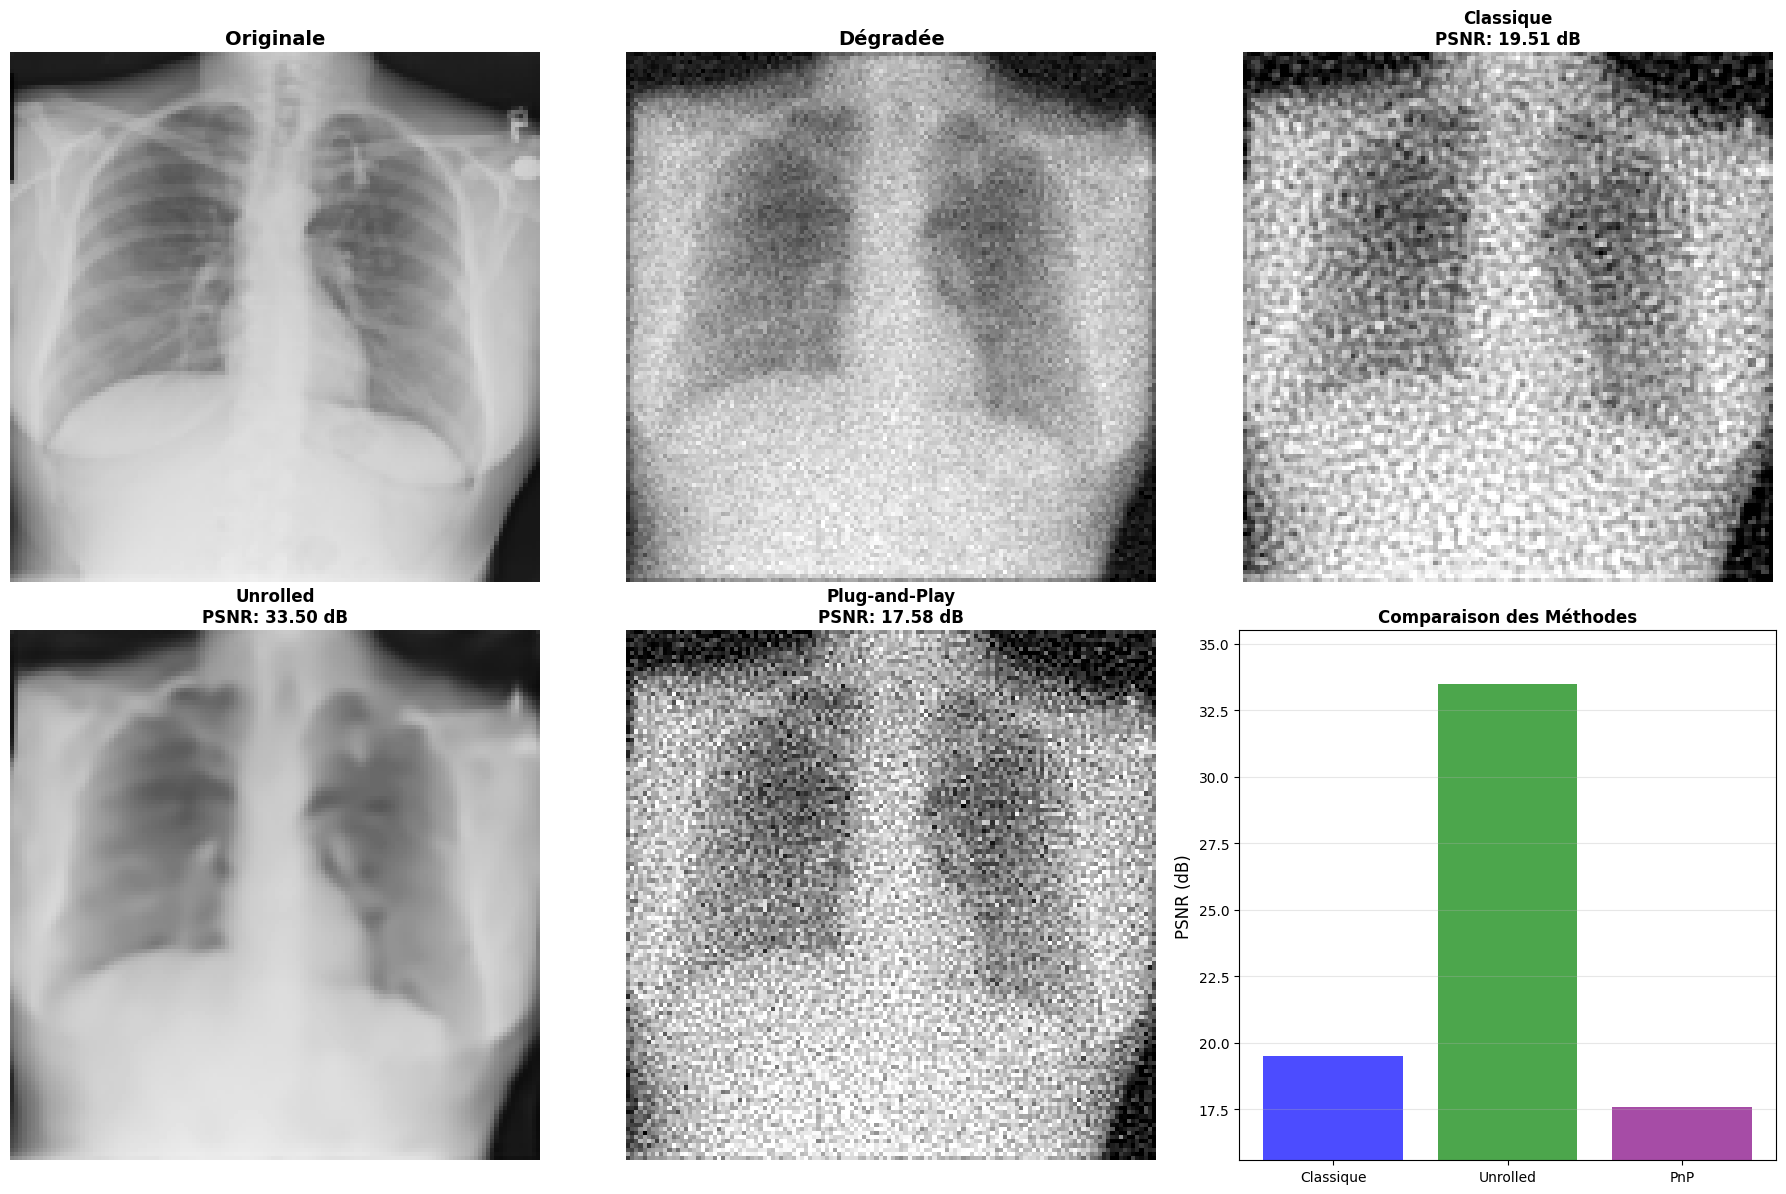


 📸 IMAGE DE TEST 4/5

🔵 Méthode 1: Optimisation Classique (Gradient Descent)

📊 Optimisation Classique:
   Dégradée  -> PSNR: 24.65 dB, SSIM: 0.5129
   Restaurée -> PSNR: 19.31 dB, SSIM: 0.2751
   Amélioration: +-5.34 dB

🟢 Méthode 2: Réseau Unrolled

📊 Réseau Unrolled:
   Dégradée  -> PSNR: 24.65 dB, SSIM: 0.5129
   Restaurée -> PSNR: 31.31 dB, SSIM: 0.8652
   Amélioration: +6.66 dB

🟣 Méthode 3: Plug-and-Play (DnCNN)

📊 Plug-and-Play:
   Dégradée  -> PSNR: 24.65 dB, SSIM: 0.5129
   Restaurée -> PSNR: 17.38 dB, SSIM: 0.1965
   Amélioration: +-7.27 dB

💾 Comparaison sauvegardée: /content/results/comparison_all_methods.png


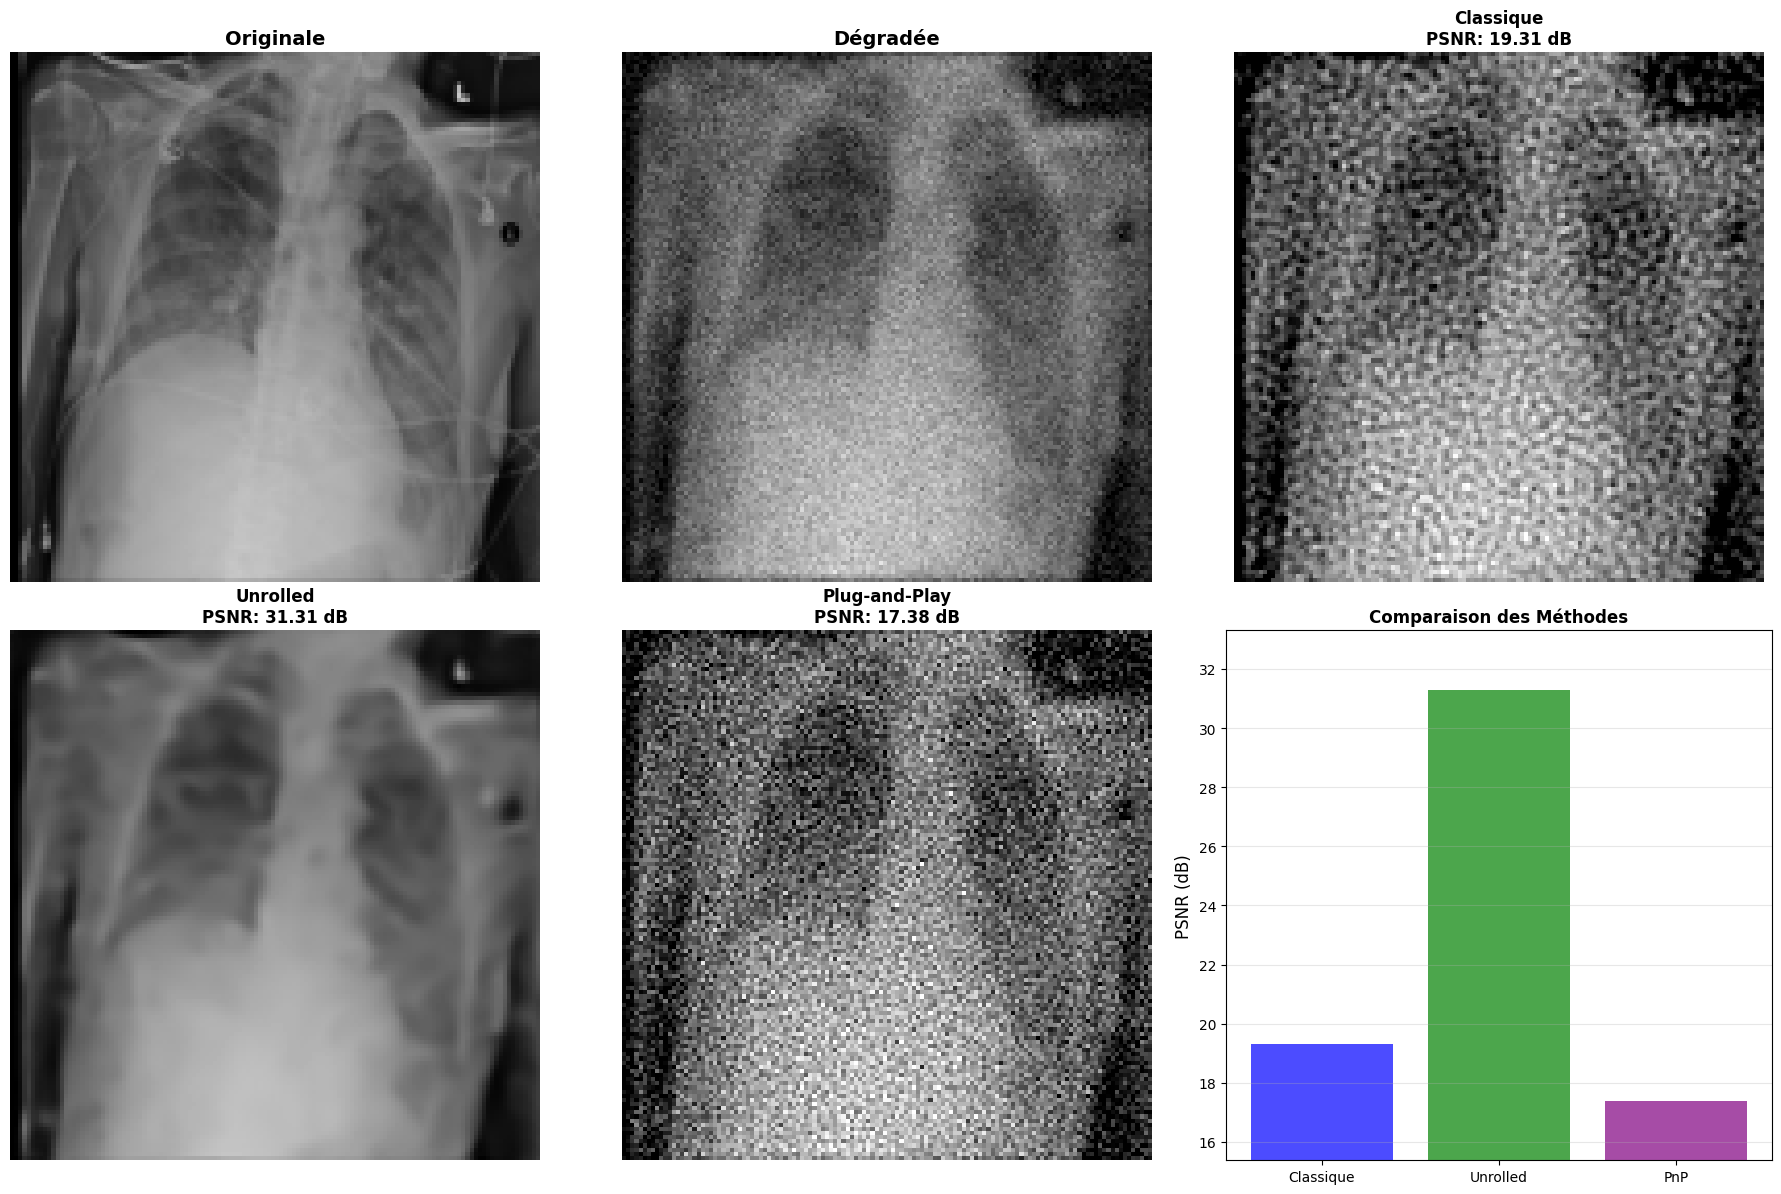


 📸 IMAGE DE TEST 5/5

🔵 Méthode 1: Optimisation Classique (Gradient Descent)

📊 Optimisation Classique:
   Dégradée  -> PSNR: 24.72 dB, SSIM: 0.5633
   Restaurée -> PSNR: 19.63 dB, SSIM: 0.3313
   Amélioration: +-5.09 dB

🟢 Méthode 2: Réseau Unrolled

📊 Réseau Unrolled:
   Dégradée  -> PSNR: 24.72 dB, SSIM: 0.5633
   Restaurée -> PSNR: 33.06 dB, SSIM: 0.9164
   Amélioration: +8.34 dB

🟣 Méthode 3: Plug-and-Play (DnCNN)

📊 Plug-and-Play:
   Dégradée  -> PSNR: 24.72 dB, SSIM: 0.5633
   Restaurée -> PSNR: 17.52 dB, SSIM: 0.2465
   Amélioration: +-7.20 dB

💾 Comparaison sauvegardée: /content/results/comparison_all_methods.png


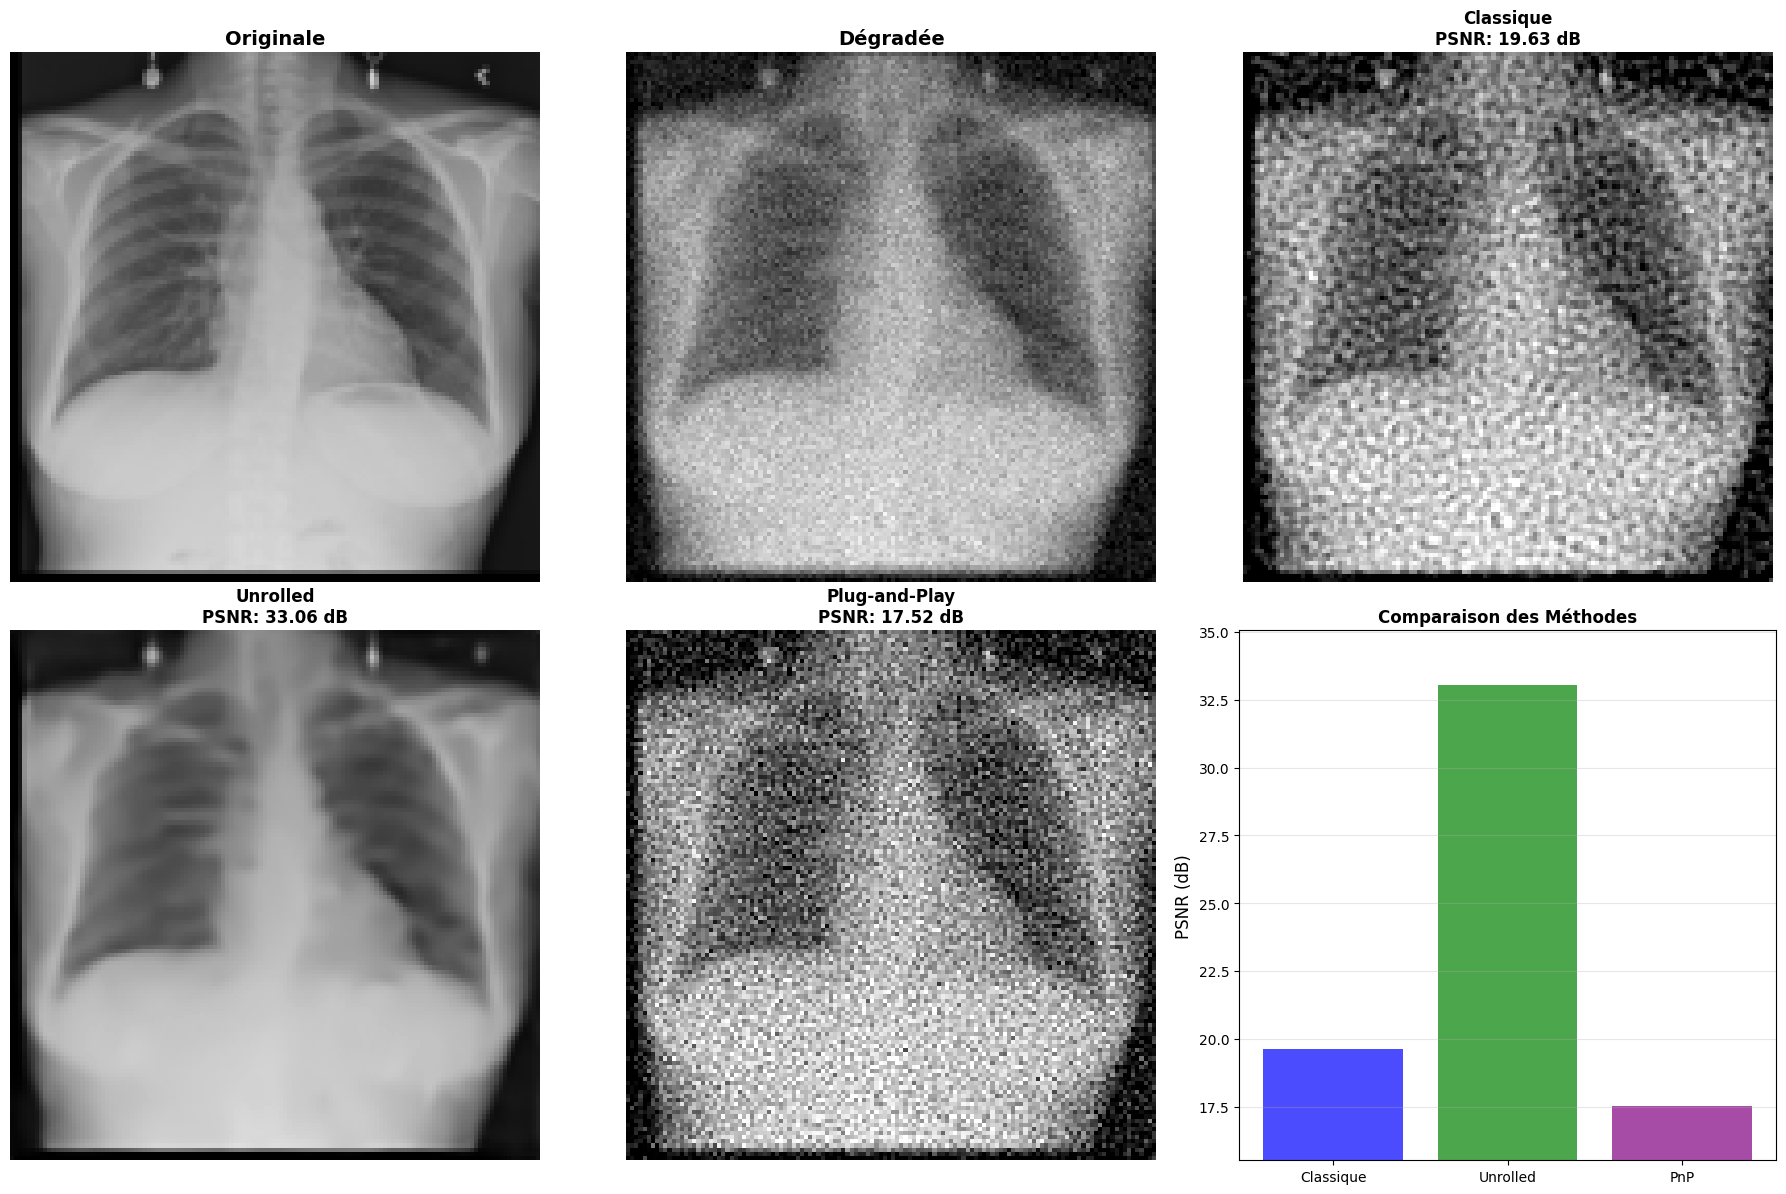


 📈 STATISTIQUES GLOBALES (5 IMAGES)

🎯 Optimisation Classique:
   PSNR moyen: 19.52 dB
   SSIM moyen: 0.3185
   Amélioration moyenne: +-4.91 dB

🎯 Réseau Unrolled:
   PSNR moyen: 31.88 dB
   SSIM moyen: 0.8873
   Amélioration moyenne: +7.45 dB

🎯 Plug-and-Play:
   PSNR moyen: 17.51 dB
   SSIM moyen: 0.2320
   Amélioration moyenne: +-6.93 dB

 ✅ ÉVALUATION TERMINÉE!


In [16]:
print("\n" + "="*80)
print(" 📊 ÉVALUATION SUR LE DATASET DE TEST")
print("="*80 + "\n")

# Sélection de 5 images de test
test_images = []
for i, img in enumerate(test_loader):
    if i >= 5:  # Prendre 5 images
        break
    test_images.append(img)

# Évaluation sur chaque image
all_results = []
for idx, test_img in enumerate(test_images):
    print(f"\n{'='*80}")
    print(f" 📸 IMAGE DE TEST {idx+1}/5")
    print('='*80)
    results = compare_all_methods(test_img[0], CONFIG)
    all_results.append(results)

# Statistiques globales
print("\n" + "="*80)
print(" 📈 STATISTIQUES GLOBALES (5 IMAGES)")
print("="*80 + "\n")

methods = ['classical', 'unrolled', 'pnp']
method_names = ['Optimisation Classique', 'Réseau Unrolled', 'Plug-and-Play']

for method, name in zip(methods, method_names):
    avg_psnr = np.mean([r[method]['psnr_reconstructed'] for r in all_results])
    avg_ssim = np.mean([r[method]['ssim_reconstructed'] for r in all_results])
    avg_improvement = np.mean([r[method]['improvement'] for r in all_results])

    print(f"🎯 {name}:")
    print(f"   PSNR moyen: {avg_psnr:.2f} dB")
    print(f"   SSIM moyen: {avg_ssim:.4f}")
    print(f"   Amélioration moyenne: +{avg_improvement:.2f} dB\n")

print("="*80)
print(" ✅ ÉVALUATION TERMINÉE!")
print("="*80)


In [17]:
print("\n" + "="*80)
print(" 🎉 PROJET TERMINÉ AVEC SUCCÈS!")
print("="*80 + "\n")

print("📊 Résumé de l'exécution:")
print(f"   ✅ Dataset: {CONFIG['MAX_TRAIN_SAMPLES'] + CONFIG['MAX_TEST_SAMPLES']} images")
print(f"   ✅ Entraînement: {CONFIG['NUM_EPOCHS']} epochs")
print(f"   ✅ Méthodes évaluées: 3")
print(f"   ✅ Images de test: 5\n")

print("📁 Fichiers générés:")
print(f"   📂 Résultats: {CONFIG['SAVE_DIR']}/")
print(f"      - comparison_all_methods.png")
print(f"      - denoiser_training.png")
print(f"      - unrolled_training.png\n")
print(f"   📂 Checkpoints: {CONFIG['CHECKPOINT_DIR']}/")
print(f"      - denoiser_epoch_5.pth ... denoiser_epoch_20.pth")
print(f"      - unrolled_epoch_5.pth ... unrolled_epoch_20.pth\n")

print("🎓 Prochaines étapes:")
print("   1. Téléchargez les résultats depuis /content/results/")
print("   2. Consultez les visualisations")
print("   3. Préparez votre présentation")
print("   4. Rédigez votre rapport\n")

print("="*80)
print(" 🚀 FÉLICITATIONS! VOTRE PROJET EST COMPLET!")
print("="*80)



 🎉 PROJET TERMINÉ AVEC SUCCÈS!

📊 Résumé de l'exécution:
   ✅ Dataset: 11000 images
   ✅ Entraînement: 20 epochs
   ✅ Méthodes évaluées: 3
   ✅ Images de test: 5

📁 Fichiers générés:
   📂 Résultats: /content/results/
      - comparison_all_methods.png
      - denoiser_training.png
      - unrolled_training.png

   📂 Checkpoints: /content/checkpoints/
      - denoiser_epoch_5.pth ... denoiser_epoch_20.pth
      - unrolled_epoch_5.pth ... unrolled_epoch_20.pth

🎓 Prochaines étapes:
   1. Téléchargez les résultats depuis /content/results/
   2. Consultez les visualisations
   3. Préparez votre présentation
   4. Rédigez votre rapport

 🚀 FÉLICITATIONS! VOTRE PROJET EST COMPLET!
